<a href="https://colab.research.google.com/github/codebymamoona/Progree-AI-Internship-Tasks/blob/main/NLP_Text_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#TASK 2_Sentiment_Classifier
import nltk
import numpy as np
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

# Download required NLTK resources
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")

# --- 1. BALANCED DATASET ---
# Multi-class categories: 0 = Negative, 1 = Neutral, 2 = Positive
raw_texts = [
    # Negative (0)
    "The software crashes constantly and fails to load data.",
    "Extremely slow performance and terrible user interface.",
    "Errors keep occurring during the build phase.",
    "Poor user experience and unreliable execution.",
    "The system fails repeatedly under high stress workloads.",
    "Frequent bugs make this application completely unusable.",
    "Worst tool ever, constantly throwing fatal exceptions.",
    "Data corruption happened during file save operations.",
    # Neutral (1)
    "The platform operates as expected without major issues.",
    "This system is acceptable, though it lacks modern features.",
    "The documentation is standard and covers the basics well.",
    "System completed tasks within default parameter bounds.",
    "Application behavior matches the standard documentation.",
    "Average performance with basic features included.",
    "Output generated according to default structural settings.",
    "The software updated properly following the guide.",
    # Positive (2)
    "Outstanding framework! Runs efficiently and handles tasks seamlessly.",
    "An absolute pleasure to use, highly recommended for developers.",
    "Brilliant performance and clean execution.",
    "Fast processing speeds and very robust error handling.",
    "Excellent user interface with intuitive controls.",
    "Highly reliable code base with exceptional output quality.",
    "Loved working with this platform, smooth integration experience.",
    "Flawless execution and impressive performance optimization.",
]

labels = [0] * 8 + [1] * 8 + [2] * 8  # 24 total balanced samples


# --- 2. TEXT PREPROCESSING ---
def preprocess_text(text: str) -> str:
    """Removes stop-words and applies lemmatization to unstructured text."""
    stop_words = set(stopwords.words("english"))
    lemmatizer = WordNetLemmatizer()

    tokens = word_tokenize(text.lower())
    cleaned_tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token.isalnum() and token not in stop_words
    ]
    return " ".join(cleaned_tokens)


clean_texts = [preprocess_text(doc) for doc in raw_texts]

# --- 3. STRATIFIED SPLIT & TF-IDF VECTORIZATION ---
X_train, X_test, y_train, y_test = train_test_split(
    clean_texts, labels, test_size=0.25, random_state=42, stratify=labels
)

vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# --- 4. CLASSIFIER TRAINING ---
classifier = LogisticRegression(random_state=42)
classifier.fit(X_train_tfidf, y_train)

# --- 5. EVALUATION METRICS ---
y_pred = classifier.predict(X_test_tfidf)

macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print("=== EVALUATION METRICS ===")
print(f"Macro F1-Score:    {macro_f1:.4f}")
print(f"Weighted F1-Score: {weighted_f1:.4f}\n")

print("=== CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative (0)", "Neutral (1)", "Positive (2)"],
        zero_division=0,
    )
)

print("=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred))

=== EVALUATION METRICS ===
Macro F1-Score:    0.3556
Weighted F1-Score: 0.3556

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

Negative (0)       0.33      0.50      0.40         2
 Neutral (1)       1.00      0.50      0.67         2
Positive (2)       0.00      0.00      0.00         2

    accuracy                           0.33         6
   macro avg       0.44      0.33      0.36         6
weighted avg       0.44      0.33      0.36         6

=== CONFUSION MATRIX ===
[[1 0 1]
 [0 1 1]
 [2 0 0]]


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
# 1. Install sentence-transformers Pre-trained Sentence Embeddings (PyTorch / HuggingFace)
!pip install -q sentence-transformers

import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

# --- DATASET ---
raw_texts = [
    # Negative (0)
    "The software crashes constantly and fails to load data.",
    "Extremely slow performance and terrible user interface.",
    "Errors keep occurring during the build phase.",
    "Poor user experience and unreliable execution.",
    "The system fails repeatedly under high stress workloads.",
    "Frequent bugs make this application completely unusable.",
    "Worst tool ever, constantly throwing fatal exceptions.",
    "Data corruption happened during file save operations.",
    # Neutral (1)
    "The platform operates as expected without major issues.",
    "This system is acceptable, though it lacks modern features.",
    "The documentation is standard and covers the basics well.",
    "System completed tasks within default parameter bounds.",
    "Application behavior matches the standard documentation.",
    "Average performance with basic features included.",
    "Output generated according to default structural settings.",
    "The software updated properly following the guide.",
    # Positive (2)
    "Outstanding framework! Runs efficiently and handles tasks seamlessly.",
    "An absolute pleasure to use, highly recommended for developers.",
    "Brilliant performance and clean execution.",
    "Fast processing speeds and very robust error handling.",
    "Excellent user interface with intuitive controls.",
    "Highly reliable code base with exceptional output quality.",
    "Loved working with this platform, smooth integration experience.",
    "Flawless execution and impressive performance optimization.",
]

labels = [0] * 8 + [1] * 8 + [2] * 8

# --- 2. GENERATE DENSE EMBEDDINGS ---
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(raw_texts)

# --- 3. TRAIN / TEST SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels, test_size=0.25, random_state=42, stratify=labels
)

# --- 4. CLASSIFICATION ---
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

# --- 5. EVALUATION METRICS ---
print("=== EVALUATION METRICS ===")
print(f"Macro F1-Score:    {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Weighted F1-Score: {f1_score(y_test, y_pred, average='weighted'):.4f}\n")

print("=== CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative (0)", "Neutral (1)", "Positive (2)"],
    )
)

print("=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred))


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

=== EVALUATION METRICS ===
Macro F1-Score:    1.0000
Weighted F1-Score: 1.0000

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

Negative (0)       1.00      1.00      1.00         2
 Neutral (1)       1.00      1.00      1.00         2
Positive (2)       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6

=== CONFUSION MATRIX ===
[[2 0 0]
 [0 2 0]
 [0 0 2]]


=== A* PATHFINDING AGENT METRICS ===
Path Found:          YES
Path Step Count:     38 steps
Expanded Nodes:      227 cells
Node Density Searched:56.75% of grid
Execution Runtime:   0.710 ms


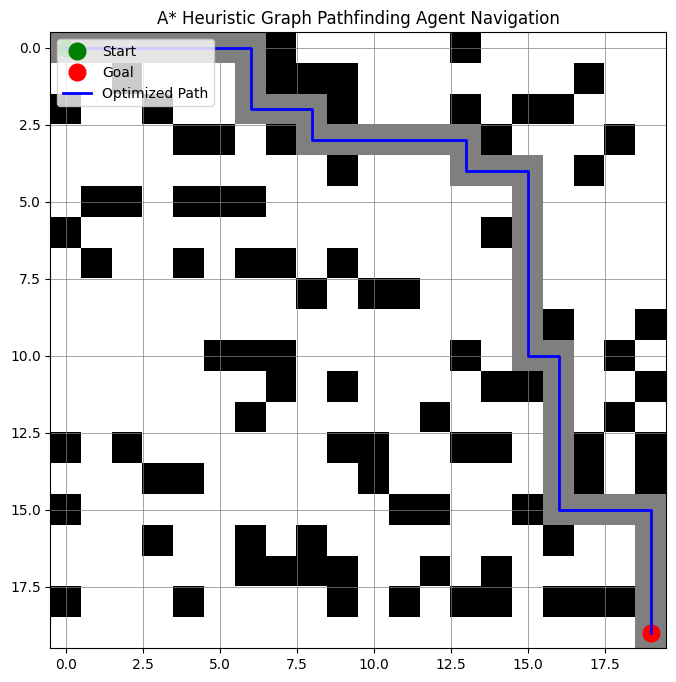

In [ ]:
#Task 3 Implementation: A* Pathfinding Search Engine
import heapq
import random
import time
import matplotlib.pyplot as plt
import numpy as np


class AStarAgent:

    def __init__(self, grid):
        self.grid = grid
        self.rows = len(grid)
        self.cols = len(grid[0])
        self.expanded_nodes = 0

    def heuristic(self, a, b):
        """Manhattan distance heuristic function."""
        return abs(a[0] - b[0]) + abs(a[1] - b[1])

    def get_neighbors(self, node):
        """Find valid 4-directional neighboring cells."""
        neighbors = []
        directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # Up, Down, Left, Right
        for dx, dy in directions:
            nx, ny = node[0] + dx, node[1] + dy
            # Check bounds and ensure cell is not an obstacle (1)
            if (
                0 <= nx < self.rows
                and 0 <= ny < self.cols
                and self.grid[nx][ny] == 0
            ):
                neighbors.append((nx, ny))
        return neighbors

    def search(self, start, goal):
        """Executes A* search algorithm from start to goal."""
        start_time = time.perf_counter()

        # Priority queue stores tuples: (f_score, node)
        open_set = []
        heapq.heappush(open_set, (0, start))

        came_from = {}
        g_score = {start: 0}
        f_score = {start: self.heuristic(start, goal)}

        closed_set = set()

        while open_set:
            _, current = heapq.heappop(open_set)

            if current in closed_set:
                continue

            closed_set.add(current)
            self.expanded_nodes += 1

            # Goal test
            if current == goal:
                runtime = (time.perf_counter() - start_time) * 1000  # in ms
                path = self.reconstruct_path(came_from, current)
                return path, runtime

            for neighbor in self.get_neighbors(current):
                tentative_g = g_score[current] + 1

                if neighbor not in g_score or tentative_g < g_score[neighbor]:
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g
                    f = tentative_g + self.heuristic(neighbor, goal)
                    f_score[neighbor] = f
                    heapq.heappush(open_set, (f, neighbor))

        runtime = (time.perf_counter() - start_time) * 1000
        return None, runtime  # No path found

    def reconstruct_path(self, came_from, current):
        path = [current]
        while current in came_from:
            current = came_from[current]
            path.append(current)
        path.reverse()
        return path


# --- 1. GENERATE GRID MAZE ---
def generate_grid(rows, cols, obstacle_density=0.25, seed=42):
    random.seed(seed)
    grid = np.zeros((rows, cols), dtype=int)
    for r in range(rows):
        for c in range(cols):
            if random.random() < obstacle_density:
                grid[r][c] = 1
    return grid


# Environment Setup
GRID_SIZE = 20
grid = generate_grid(GRID_SIZE, GRID_SIZE, obstacle_density=0.20, seed=10)

start = (0, 0)
goal = (GRID_SIZE - 1, GRID_SIZE - 1)

# Ensure start and goal are walkable
grid[start[0]][start[1]] = 0
grid[goal[0]][goal[1]] = 0

# --- 2. RUN SEARCH AGENT ---
agent = AStarAgent(grid)
path, runtime = agent.search(start, goal)

# --- 3. DISPLAY PERFORMANCE METRICS ---
print("=== A* PATHFINDING AGENT METRICS ===")
if path:
    total_cells = GRID_SIZE * GRID_SIZE
    density = (agent.expanded_nodes / total_cells) * 100
    print(f"Path Found:          YES")
    print(f"Path Step Count:     {len(path) - 1} steps")
    print(f"Expanded Nodes:      {agent.expanded_nodes} cells")
    print(f"Node Density Searched:{density:.2f}% of grid")
    print(f"Execution Runtime:   {runtime:.3f} ms")
else:
    print("Path Found: NO (Obstacles blocked the route)")

# --- 4. VISUALIZE PATH MATRIX ---
plt.figure(figsize=(8, 8))
display_grid = np.array(grid, dtype=float)

# Plot path on visual map
if path:
    for r, c in path:
        display_grid[r][c] = 0.5  # Path marker

plt.imshow(display_grid, cmap="binary")

# Mark Start and Goal
plt.plot(start[1], start[0], "go", markersize=12, label="Start")
plt.plot(goal[1], goal[0], "ro", markersize=12, label="Goal")

if path:
    path_y, path_x = zip(*path)
    plt.plot(path_x, path_y, "b-", linewidth=2, label="Optimized Path")

plt.title("A* Heuristic Graph Pathfinding Agent Navigation")
plt.legend(loc="upper left")
plt.grid(True, which="both", color="gray", linestyle="-", linewidth=0.5)
plt.show()

=== COMPUTER VISION PIPELINE PERFORMANCE METRICS ===
Total Target Objects Tracked: 4
Object ID 1: Area = 6007 px | Bounds (x,y,w,h) = (60, 249, 121, 102)
Object ID 2: Area = 14000 px | Bounds (x,y,w,h) = (450, 80, 101, 141)
Object ID 3: Area = 11116 px | Bounds (x,y,w,h) = (261, 61, 119, 119)
Object ID 4: Area = 16900 px | Bounds (x,y,w,h) = (50, 50, 131, 131)


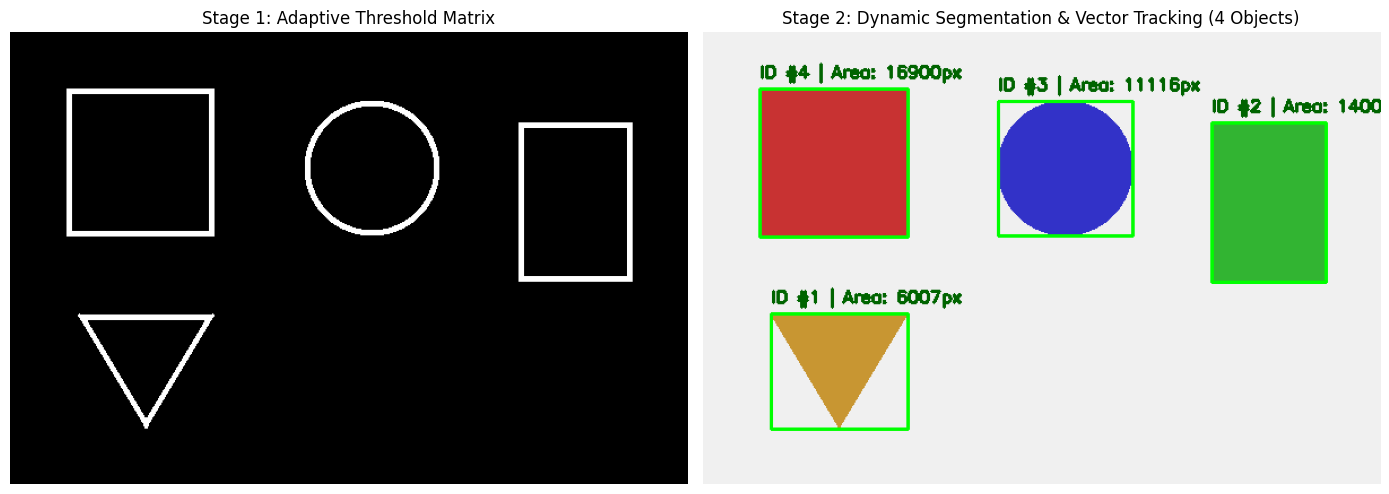

In [ ]:
# Task 4 computer vision pipeline using OpenCV
import cv2
import matplotlib.pyplot as plt
import numpy as np

# --- 1. GENERATE SYNTHETIC FRAME FOR TESTING ---
# Creates a simulated frame containing multiple target geometric shapes
height, width = 400, 600
synthetic_frame = (
    np.ones((height, width, 3), dtype=np.uint8) * 240
)  # Light background

# Draw sample target objects
cv2.rectangle(
    synthetic_frame, (50, 50), (180, 180), (50, 50, 200), -1
)  # Red Square
cv2.circle(
    synthetic_frame, (320, 120), 60, (200, 50, 50), -1
)  # Blue Circle
cv2.rectangle(
    synthetic_frame, (450, 80), (550, 220), (50, 180, 50), -1
)  # Green Rectangle
pts = np.array([[120, 350], [60, 250], [180, 250]], np.int32)
cv2.fillPoly(synthetic_frame, [pts], (50, 150, 200))  # Orange Triangle


# --- 2. CV PROCESSING PIPELINE ---
def process_cv_frame(image):
    # Convert to Grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian Blur Filter
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Apply Adaptive Thresholding
    thresh = cv2.adaptiveThreshold(
        blurred,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        11,
        2,
    )

    # Extract Contours / Pixel Bounds
    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    annotated_image = image.copy()
    detection_log = []

    object_count = 0
    for contour in contours:
        area = cv2.contourArea(contour)
        if area > 500:  # Filter noise / small pixel bounds
            object_count += 1

            # Get Bounding Box Vectors
            x, y, w, h = cv2.boundingRect(contour)

            # Overlay Bounding Box
            cv2.rectangle(
                annotated_image, (x, y), (x + w, y + h), (0, 255, 0), 2
            )

            # Overlay Dynamic Class & Count Text Vector
            label = f"ID #{object_count} | Area: {int(area)}px"
            cv2.putText(
                annotated_image,
                label,
                (x, max(y - 10, 15)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 100, 0),
                2,
            )

            detection_log.append(
                {
                    "ID": object_count,
                    "Area_PX": int(area),
                    "Bounding_Box": (x, y, w, h),
                }
            )

    return annotated_image, thresh, detection_log, object_count


# Execute Pipeline
processed_img, threshold_mask, log, total_detected = process_cv_frame(
    synthetic_frame
)

# --- 3. METRICS OUTPUT ---
print("=== COMPUTER VISION PIPELINE PERFORMANCE METRICS ===")
print(f"Total Target Objects Tracked: {total_detected}")
for obj in log:
    print(
        f"Object ID {obj['ID']}: Area = {obj['Area_PX']} px | Bounds (x,y,w,h) = {obj['Bounding_Box']}"
    )

# --- 4. VISUALIZE PIPELINE STAGES ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cv2.cvtColor(threshold_mask, cv2.COLOR_GRAY2RGB))
axes[0].set_title("Stage 1: Adaptive Threshold Matrix")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(processed_img, cv2.COLOR_BGR2RGB))
axes[1].set_title(
    f"Stage 2: Dynamic Segmentation & Vector Tracking ({total_detected} Objects)"
)
axes[1].axis("off")

plt.tight_layout()
plt.show()